# Ch 7. CNN

## 전체 구조
CNN의 네트워크 구조를 보며 전체 틀을 이해하자. CNN도 신경망과 같이 계층을 조합하여 만들 수 있다. 다만 합성곱 계층과 폴링 계층이 새롭게 등장한다.  
지금까지의 신경망은 인접하는 계층의 모든 뉴런과 결합되어 있고 이를 완전결합이라하며 이런 계층을 Affine 계층이라는 이름으로 구현했다. 이 계층 뒤에 활성화 함수를 갖는 ReLU 계층이 이어진다. 이 계층들이 이어지다 소프트맥스 계층에서 결과를 출력한다.  
CNN은 어떻게 다를까? 합성곱 계층 - ReLU 계층 - 풀링 계층(생략 하기도 함)로 구성되어 있다. 그리고 출력에 가까운 층은 Affine 계층을 사용할 수 있고 마지막 출력 계층에서는 Affine-Softmax조합을 사용한다. 

## 합성곱 계층
### Affine 계층의 문제점
바로 데이터의 형상이 무시된다. 예를 들어 mnist 데이터 셋의 사진을 그냥 평평한 1차원 데이터로 평탄화 시켜버린다. 그러나 합성곱 계층은 형상을 유지한다. 예를 들어 이미지의 3차원 데이터 입력을 다음 계층에도 3차원 데이터로 전달한다. 그래서 형상을 가진 데이터를 제대로 이해할 가능성이 있다.  
합성곱 계층의 입출력 데이터를 특징 맵이라고 한다. 

### 합성곱 연산
합성곱 계층에서는 합성곱 연산을 처리한다. 합성곱 연산은 필터 연산에 해당한다. 그리고 필터와 입력 간의 연산은 서로 대응하는 원소를 곱한 후 그 총합을 구하는 방법인데 이 계산을 단일 곱셈 누산이라 한다.  
완전 연결 신경망에서는 가중치 매개변수와 편향이 존재하는데 CNN에서는 필터의 매개변수가 가중치에 해당하고 편향도 존재한다. 

### 패딩
합성곱 연산을 수행하기 전에 입력 데이터 주변을 특정 값으로 채우는데 이를 패딩이라고 하고 합성곱 연산에서 자주 사용한다. 패딩은 출력의 크기를 조정할 목적으로 사용한다. 왜냐하면 합성곱 연산을 진행하면 출력의 행렬 크기가 줄어들기 때문이다.  

### 스트라이드
필터를 적용하는 위치의 간격을 스트라이드라고 한다. 예를 들면 스트라이드를 2로 하면 필터를 적용하는 윈도우가 두 칸씩 이동합니다. 입력 크기(H, W), 필터 크기(FH, FW), 출력 크기(OH, OW), 패딩 P, 스트라이드 S라 할 떄 출력 크기는 다음 식이다. $OH = \frac{H + 2P - FH}{S}  + 1$, $OW = \frac{W + 2P - FW}{S}  + 1$

### 3차원 데이터의 합성곱 연산, 블록으로 생각하기
입력 데이터의 채널 수와 필터의 채널 수가 같아야 한다. 필터의 크기는 상관 없다.  
(C, H, W) * (C, FH, FW) = (1, OH, OW) , (C, H, W) * (FN, C, FH, FW) + (FN, 1, 1)[편향] = (FN, OH, OW)

### 배치 처리
입력 데이터들을한 덩어리로 묶어서 배치로 처리 해보자.  
(N, C, H, W) * (FN, C, FH, FW) + (N, FN, 1, 1) = (N, FN, OH, OW)


## 폴링 계층
세로, 가로 방향의 공간을 줄이는 연산이다. 최대 풀링은 최대값을 구하는 연산이다. 그리고 평균 풀링도 있다. 하지만 이미지 인식 분야에서는 주로 최대 풀링을 사용한다.  
### 풀링 계층의 특징
* 학습해야 할 매개변수가 없다.
* 채널 수가 변하지 않는다.
* 입력의 변화에 영향을 적게 받는다.

## 합성곱/풀링 계층 구현하기
CNN에서 계층 사이를 흐르는 데이터는 4차원이다. 그러면 합성곱 연산 구현이 중첩 for문에 매우 복잡할 것 같지만 im2col이라는 편의 함수로 간단하게 구현할 수 있다.

### im2col
이 함수는 입력 데이터를 필터링(가중치 연산)하기 좋게 전개하는 함수이다. 3차원 입력데이터에서 필터를 적용하는 영역을 한 줄로 늘어 놓아 2차원 행렬로 바꾸어준다. 하지만 실제 상황에서 영역이 겹치는 경우가 많은데 이때 필터 적용 영역이 겹치게 되면서 전개 한 후의 원소의 수가 원래 블록의 수보다 많아진다. 그래서 메모리를 많이 소비하는 단점이 있다. 하지만 SIMD 같이 큰 행렬을 묶어 계산하는데 최적화 되어 있어 빠르게 계산 가능하다. 그래서 2차원 행렬로 계산 한 뒤에 4차원으로 변형한다. 

파이토치를 이용해 구현하자

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init

import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu130
True


In [2]:
batch_size = 256
learning_rate = .0002
num_epoch = 10

In [3]:
mnist_train = dset.MNIST(root="../dataset", train=True, transform=transforms.ToTensor(), target_transform=None, download=True)
mnist_test = dset.MNIST(root="../dataset", train=False, transform=transforms.ToTensor(), target_transform=None, download=True)

In [4]:
print(mnist_train.__getitem__(0)[0].size(), mnist_train.__len__())
print(mnist_test.__getitem__(0)[0].size(), mnist_test.__len__())

print(len(mnist_train), len(mnist_test))


torch.Size([1, 28, 28]) 60000
torch.Size([1, 28, 28]) 10000
60000 10000


In [5]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=True)

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 3 * 3, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        out = self.layer(x)
        out = out.view(batch_size, -1)

        out = self.fc_layer(out)
        return out

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

model = CNN().to(device)

loss_func = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

cuda:0


In [9]:
loss_arr = []
for i in range(num_epoch):
    for j, [image, label] in enumerate(train_loader):
        x = image.to(device)
        y_ = label.to(device)

        optimizer.zero_grad()
        output = model.forward(x)
        loss = loss_func(output, y_)
        loss.backward()
        optimizer.step()

        if j % 1000 == 0:
            print(loss)
            loss_arr.append(loss.cpu().detach().numpy())

tensor(2.3069, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.2181, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.1517, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.1076, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0638, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0803, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0682, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0513, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.1315, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0445, device='cuda:0', grad_fn=<NllLossBackward0>)


In [10]:
param_list = list(model.parameters())
print(param_list)

[Parameter containing:
tensor([[[[-0.0945, -0.0610, -0.1250, -0.0282,  0.1670],
          [-0.1495, -0.1069, -0.0229, -0.0388,  0.1654],
          [-0.1320,  0.2231, -0.0877,  0.2173,  0.1575],
          [ 0.0858,  0.1859,  0.0275, -0.0368,  0.1354],
          [ 0.2898, -0.0845,  0.2026,  0.0536, -0.0610]]],


        [[[ 0.1535,  0.1473,  0.1087,  0.2511,  0.1889],
          [-0.0090,  0.1754,  0.0779,  0.2635,  0.2426],
          [-0.1872, -0.1467,  0.1717, -0.1144, -0.0632],
          [-0.1004,  0.1261,  0.1294,  0.1742, -0.1728],
          [-0.1477,  0.0523,  0.0989, -0.1005,  0.0207]]],


        [[[ 0.1177, -0.0797,  0.1834,  0.1838, -0.0894],
          [ 0.0226,  0.1375, -0.0359, -0.0134,  0.0642],
          [ 0.0422, -0.0156, -0.0192,  0.1065,  0.1861],
          [-0.1487,  0.0868, -0.0234, -0.0922,  0.0205],
          [-0.1731,  0.1382,  0.1792,  0.2351,  0.2162]]],


        [[[ 0.2277, -0.0775,  0.2275, -0.0876,  0.1396],
          [-0.0665, -0.1944,  0.0607, -0.1145, -0.149

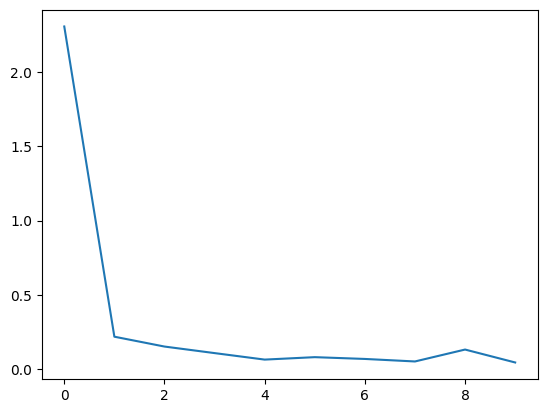

In [13]:
plt.plot(loss_arr)
plt.show()

In [14]:
correct = 0
total = 0

with torch.no_grad():
    for image, label in test_loader:
        x = image.to(device)
        y_ = label.to(device)

        output = model.forward(x)

        _, output_index = torch.max(output, 1)
        total += label.size(0)

        correct += (output_index == y_).sum().float()

    print("Accuracy of Test Data: {}%".format(100*correct/total))

Accuracy of Test Data: 98.68790435791016%
